LOADING VAHAN MAKER DATA

Shape:
(2791564, 9)

Columns:
['id', 'date', 'state_name', 'state_code', 'office_name', 'office_code', 'type', 'category', 'registrations']

First 5 rows:
   id        date                   state_name  state_code     office_name  \
0   0  2020-04-01  Andaman And Nicobar Islands          35  Port Blair Dto   
1   1  2020-04-01  Andaman And Nicobar Islands          35  Port Blair Dto   
2   2  2020-04-01  Andaman And Nicobar Islands          35  Port Blair Dto   
3   3  2020-04-01  Andaman And Nicobar Islands          35  Port Blair Dto   
4   4  2020-04-01  Andaman And Nicobar Islands          35  Port Blair Dto   

  office_code                                        type category  \
0         AN1                           Ashok Leyland Ltd    Maker   
1         AN1                          Ford India Pvt Ltd    Maker   
2         AN1                           Hero Motocorp Ltd    Maker   
3         AN1  Honda Motorcycle And Scooter India (P) Ltd    Maker   


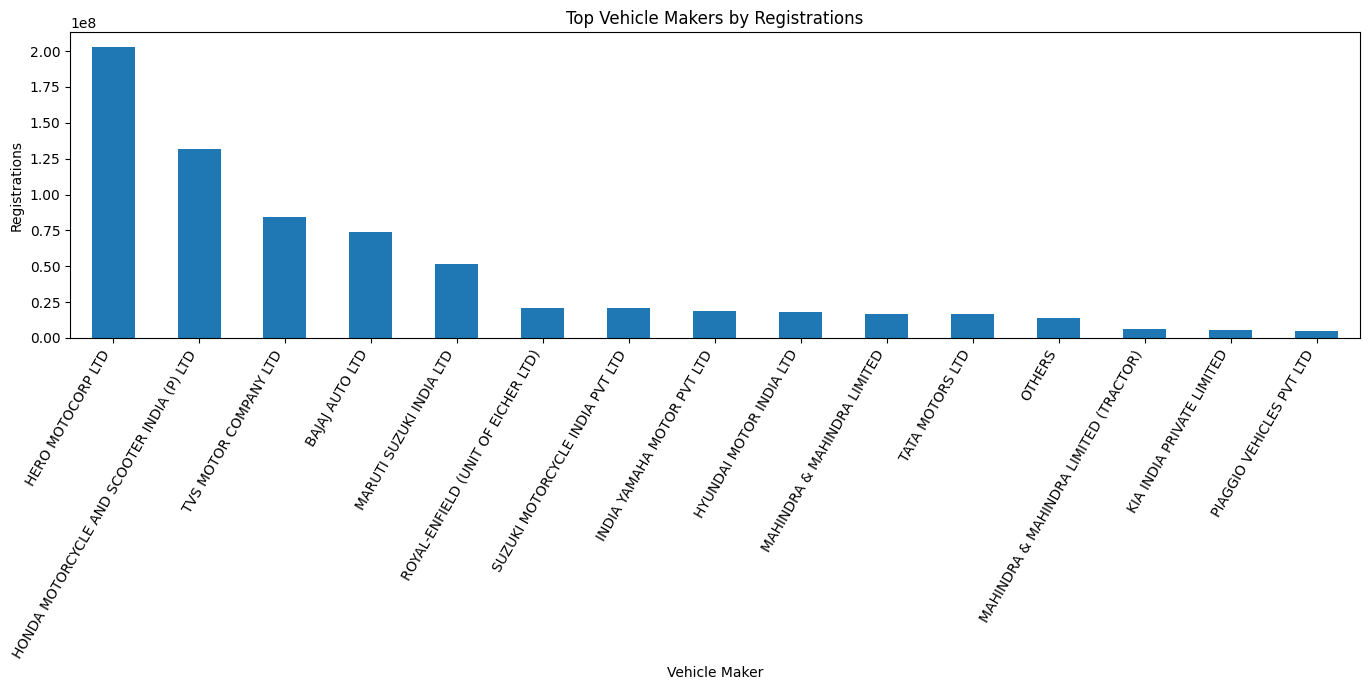

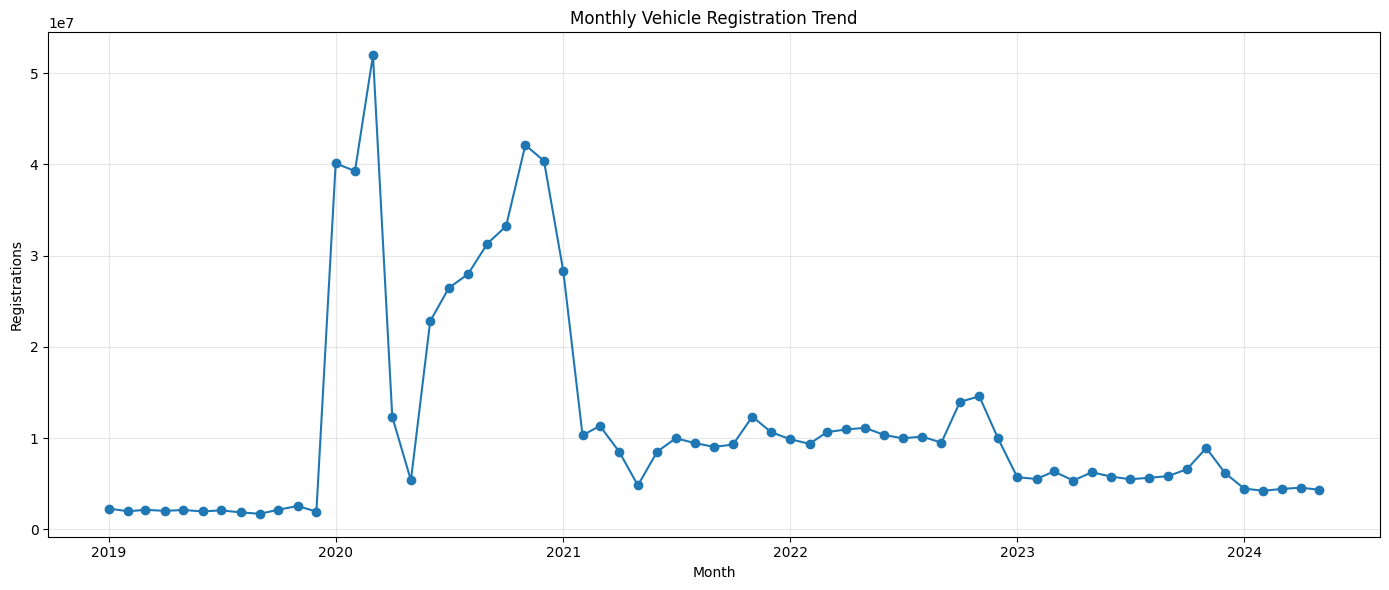

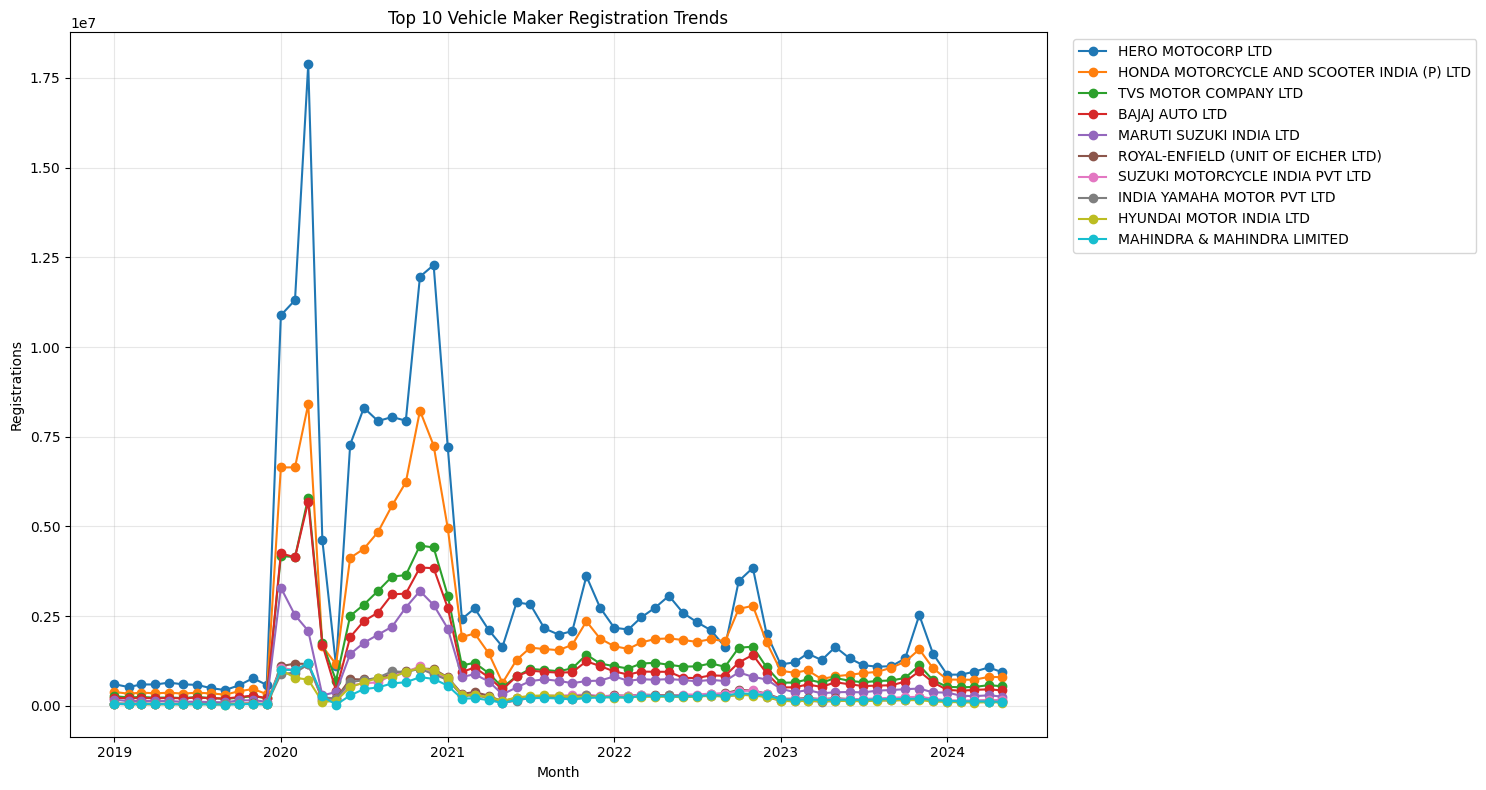


PIPELINE COMPLETED

Generated files:

data/processed/
    vahan_maker_features.csv
    state_maker_analysis.csv

outputs/
    top_makers.png
    monthly_registration_trend.png
    top_maker_trends.png



In [11]:
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


# ============================================================
# CONFIGURATION
# ============================================================

INPUT_FILE = "/content/vahan-vehicle-registrations-by-maker.csv"

PROCESSED_DIR = "data/processed"
OUTPUT_DIR = "outputs"

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# 1. LOAD DATA
# ============================================================

print("=" * 60)
print("LOADING VAHAN MAKER DATA")
print("=" * 60)

df = pd.read_csv(INPUT_FILE)

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())


# ============================================================
# 2. BASIC INFORMATION
# ============================================================

print("\n" + "=" * 60)
print("DATA INFORMATION")
print("=" * 60)

print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())


# ============================================================
# 3. REMOVE DUPLICATES
# ============================================================

df = df.drop_duplicates()

print("\nShape after removing duplicates:")
print(df.shape)


# ============================================================
# 4. CLEAN DATE
# ============================================================

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

df = df.dropna(
    subset=["date"]
)


# ============================================================
# 5. CLEAN REGISTRATIONS
# ============================================================

df["registrations"] = pd.to_numeric(
    df["registrations"],
    errors="coerce"
)

df = df.dropna(
    subset=["registrations"]
)


# ============================================================
# 6. CLEAN MAKER NAME
# ============================================================

df["maker"] = (
    df["type"]
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 7. CREATE TIME FEATURES
# ============================================================

df["year"] = df["date"].dt.year

df["month"] = df["date"].dt.month

df["quarter"] = df["date"].dt.quarter

df["year_month"] = (
    df["date"]
    .dt.to_period("M")
    .astype(str)
)


# ============================================================
# 8. CHECK MAKERS
# ============================================================

print("\n" + "=" * 60)
print("TOP VEHICLE MAKERS")
print("=" * 60)

maker_counts = (
    df.groupby("maker")["registrations"]
    .sum()
    .sort_values(ascending=False)
)

print(
    maker_counts.head(30)
)


# ============================================================
# 9. TOTAL MONTHLY REGISTRATIONS
# ============================================================

monthly = (
    df.groupby("year_month")["registrations"]
    .sum()
    .reset_index()
)

monthly["year_month"] = pd.to_datetime(
    monthly["year_month"]
)

monthly = monthly.sort_values(
    "year_month"
)

monthly = monthly.rename(
    columns={
        "registrations":
            "total_registrations"
    }
)


print("\nMonthly registrations:")
print(monthly.head())


# ============================================================
# 10. MAKER-WISE MONTHLY DATA
# ============================================================

maker_monthly = (
    df.groupby(
        [
            "year_month",
            "maker"
        ]
    )["registrations"]
    .sum()
    .reset_index()
)

maker_monthly["year_month"] = pd.to_datetime(
    maker_monthly["year_month"]
)


# ============================================================
# 11. TOP 20 MAKERS
# ============================================================

top_makers = (
    maker_monthly
    .groupby("maker")["registrations"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .index
)


top_maker_data = maker_monthly[
    maker_monthly["maker"].isin(top_makers)
].copy()


# ============================================================
# 12. PIVOT TOP MAKERS
# ============================================================

maker_features = (
    top_maker_data
    .pivot(
        index="year_month",
        columns="maker",
        values="registrations"
    )
    .fillna(0)
    .reset_index()
)


# Clean column names

def clean_column_name(column):

    column = str(column).lower()

    column = re.sub(
        r"[^a-z0-9]+",
        "_",
        column
    )

    return column.strip("_")


maker_features.columns = [
    clean_column_name(col)
    for col in maker_features.columns
]


print("\nMaker feature dataset:")
print(maker_features.head())


# ============================================================
# 13. TOP MAKER SHARE
# ============================================================

maker_columns = [
    col
    for col in maker_features.columns
    if col != "year_month"
]


maker_features["top_maker_registrations"] = (
    maker_features[maker_columns]
    .max(axis=1)
)


maker_features["top_maker_share"] = (
    maker_features["top_maker_registrations"]
    /
    maker_features[maker_columns]
    .sum(axis=1)
)


# ============================================================
# 14. TOTAL EV / MAKER DATASET
# ============================================================

maker_features["total_registrations"] = (
    maker_features[maker_columns]
    .sum(axis=1)
)


# ============================================================
# 15. GROWTH FEATURES
# ============================================================

maker_features["monthly_growth"] = (
    maker_features["total_registrations"]
    .pct_change()
    * 100
)


maker_features["rolling_mean_3"] = (
    maker_features["total_registrations"]
    .shift(1)
    .rolling(3)
    .mean()
)


maker_features["rolling_mean_6"] = (
    maker_features["total_registrations"]
    .shift(1)
    .rolling(6)
    .mean()
)


maker_features["rolling_mean_12"] = (
    maker_features["total_registrations"]
    .shift(1)
    .rolling(12)
    .mean()
)


# ============================================================
# 16. LAG FEATURES
# ============================================================

maker_features["lag_1"] = (
    maker_features["total_registrations"]
    .shift(1)
)

maker_features["lag_3"] = (
    maker_features["total_registrations"]
    .shift(3)
)

maker_features["lag_6"] = (
    maker_features["total_registrations"]
    .shift(6)
)

maker_features["lag_12"] = (
    maker_features["total_registrations"]
    .shift(12)
)


# ============================================================
# 17. SAVE PROCESSED DATA
# ============================================================

output_file = (
    f"{PROCESSED_DIR}/"
    "vahan_maker_features.csv"
)

maker_features.to_csv(
    output_file,
    index=False
)

print("\nProcessed dataset saved:")
print(output_file)


# ============================================================
# 18. STATE-WISE MAKER ANALYSIS
# ============================================================

state_maker = (
    df.groupby(
        [
            "state_name",
            "maker"
        ]
    )["registrations"]
    .sum()
    .reset_index()
)


state_maker.to_csv(
    f"{PROCESSED_DIR}/"
    "state_maker_analysis.csv",
    index=False
)


# ============================================================
# 19. STATE-WISE TOTAL REGISTRATIONS
# ============================================================

state_total = (
    df.groupby("state_name")
    ["registrations"]
    .sum()
    .sort_values(ascending=False)
)


print("\n" + "=" * 60)
print("TOP STATES")
print("=" * 60)

print(
    state_total.head(20)
)


# ============================================================
# 20. TOP MAKER VISUALIZATION
# ============================================================

plt.figure(
    figsize=(14, 7)
)

maker_counts.head(15).plot(
    kind="bar"
)

plt.title(
    "Top Vehicle Makers by Registrations"
)

plt.xlabel(
    "Vehicle Maker"
)

plt.ylabel(
    "Registrations"
)

plt.xticks(
    rotation=60,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/top_makers.png",
    dpi=300
)

plt.show()


# ============================================================
# 21. MONTHLY REGISTRATION TREND
# ============================================================

plt.figure(
    figsize=(14, 6)
)

plt.plot(
    monthly["year_month"],
    monthly["total_registrations"],
    marker="o"
)

plt.title(
    "Monthly Vehicle Registration Trend"
)

plt.xlabel(
    "Month"
)

plt.ylabel(
    "Registrations"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/monthly_registration_trend.png",
    dpi=300
)

plt.show()


# ============================================================
# 22. TOP MAKER TREND
# ============================================================

# ============================================================
# 22. TOP MAKER TREND
# ============================================================

plt.figure(figsize=(15, 8))

# top_makers is a Pandas Index, so use slicing
for maker in top_makers[:10]:

    temp = maker_monthly[
        maker_monthly["maker"] == maker
    ].sort_values("year_month")

    plt.plot(
        temp["year_month"],
        temp["registrations"],
        marker="o",
        label=maker
    )

plt.title(
    "Top 10 Vehicle Maker Registration Trends"
)

plt.xlabel("Month")
plt.ylabel("Registrations")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/top_maker_trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
# ============================================================
# FINAL
# ============================================================

print("\n" + "=" * 60)
print("PIPELINE COMPLETED")
print("=" * 60)

print(
    """
Generated files:

data/processed/
    vahan_maker_features.csv
    state_maker_analysis.csv

outputs/
    top_makers.png
    monthly_registration_trend.png
    top_maker_trends.png
"""
)